In [1]:
import os

galaxy_id = os.environ.get("GALAXY_ID")
component_str = os.environ.get("COMPONENT", None)
split_file = os.environ.get("SPLIT_FILE", "")

print("Notebook gestartet mit:")
print("GALAXY_ID =", galaxy_id)
print("COMPONENT =", component_str)
print("SPLIT_FILE =", split_file)


Notebook gestartet mit:
GALAXY_ID = g5.02e11
COMPONENT = ThinDisc,ThickDisc,Halo
SPLIT_FILE = ./data/gsf/g5.02e11.01024.gmm_full_white_jzjcejpjc_5clusters_2018tags.dat


In [2]:
if component_str is None or component_str.strip() == "" or component_str == "None":
    component = None
else:
    # split by comma and strip whitespace
    component = [c.strip() for c in component_str.split(",")]

In [3]:
# This code is run on the emiles-template branch
# This code is run on jarvis

In [4]:
from jax import config
#config.update("jax_enable_x64", True)
config.update('jax_num_cpu_devices', 8)

In [5]:
#NBVAL_SKIP
import os

# Tell XLA to fake 2 host CPU devices
#os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=3'

# Only make GPU 0 and GPU 1 visible to JAX:
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

#os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]   = "false"

import jax

# Now JAX will list two CpuDevice entries
print(jax.devices())
# → [CpuDevice(id=0), CpuDevice(id=1)]

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


In [6]:
# NBVAL_SKIP
#import os
#  os.environ['SPS_HOME'] = '/mnt/storage/annalena_data/sps_fsps'
#os.environ['SPS_HOME'] = '/home/annalena/sps_fsps'
#os.environ['SPS_HOME'] = '/Users/annalena/Documents/GitHub/fsps'
#os.environ['SPS_HOME'] = '/export/home/aschaibl/fsps'
os.environ['SPS_HOME'] = '/home/annalena_data/sps_fsps'

## Step 1: Config

In [7]:
#NBVAL_SKIP
import matplotlib.pyplot as plt
from rubix.core.pipeline import RubixPipeline 
import os

#galaxy_id = "g5.02e11"
#component = "ThinDisk" #None #"ThinDisk" #"ThickDisk" #"Halo" #"PseudoBulge"
#split_file = "./data/gsf/g5.02e11.01024.gmm_full_white_jzjcejpjc_5clusters_2018tags.dat"

config_NIHAO = {
    "pipeline":{"name": "calc_ifu_memory"},
    
    "logger": {
        "log_level": "DEBUG",
        "log_file_path": None,
        "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    },
    "data": {
        "name": "NihaoHandler",
        "args": {
            "particle_type": ["stars"],
            "save_data_path": "data",
            "snapshot": "1024",
        },
        "load_galaxy_args": {"reuse": True, "id": galaxy_id},
        "subset": {"use_subset": False, "subset_size": 200000},
    },
    "simulation": {
        "name": "NIHAO",
        "args": {
            #"path": f'/export/home/aschaibl/502e11/{galaxy_id}.01024',
            #"halo_path": f'/export/home/aschaibl/502e11/{galaxy_id}.01024.z0.000.AHF_halos',
            "path": f'/home/_data/nihao/nihao_classic/{galaxy_id}/{galaxy_id}.01024',
            "halo_path": f'/home/_data/nihao/nihao_classic/{galaxy_id}/{galaxy_id}.01024.z0.000.AHF_halos',
            "halo_id": 0,
        },
    },
    "output_path": "output",

    "telescope":
        {"name": "MUSE_WFM",
         "psf": {"name": "gaussian", "size": 5, "sigma": 0.6},
         "lsf": {"sigma": 0.5},
         "noise": {"signal_to_noise": 100,"noise_distribution": "normal"},},
    "cosmology":
        {"name": "PLANCK15"},
        
    "galaxy":
        {"dist_z": 0.01,
         "rotation": {"type": "matrix"}, #{"alpha": 0.0, "beta": 0.0, "gamma":0.0},
         "component": component,#None, #["ThinDisk", "ThickDisk", "Halo", "PseudoBulge"], #None,
         "component_file": split_file, 
        },
        
    "ssp": {
        "template": {
            "name": "EMILES" #"Mastar_CB19_SLOG_1_5" #"FSPS" #"BruzualCharlot2003" #"Mastar_CB19_SLOG_1_5"
        },
        "dust": {
                "extinction_model": "Cardelli89",
                "dust_to_gas_ratio": 0.01,
                "dust_to_metals_ratio": 0.4,
                "dust_grain_density": 3.5,
                "Rv": 3.1,
            },
    },        
}

2025-10-01 11:42:39,625 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|




2025-10-01 11:42:39,626 - rubix - INFO - Rubix version: 0.0.post479+g4322c8628


2025-10-01 11:42:39,626 - rubix - INFO - JAX version: 0.6.0


2025-10-01 11:42:39,627 - rubix - INFO - Running on [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)] devices


## Step 2: Pipeline yaml

## Step 3: Run the pipeline

After defining the `config` and the `pipeline_config` you can simply run the whole pipeline by these two lines of code.

In [8]:
#NBVAL_SKIP
pipe = RubixPipeline(config_NIHAO)

/home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
  warnings.warn(


In [9]:
#NBVAL_SKIP

inputdata = pipe.prepare_data()
rubixdata = pipe.run_sharded(inputdata)

2025-10-01 11:42:40,361 - rubix - INFO - Getting rubix data...


2025-10-01 11:42:40,362 - rubix - INFO - Loading data into input handler


2025-10-01 11:42:40,363 - rubix - INFO - Using PynbodyHandler to load a NIHAO galaxy


2025-10-01 11:42:40,366 - rubix - INFO - Galaxy redshift (dist_z) set to: 0.01


2025-10-01 11:42:40,380 - rubix - INFO - Simulation snapshot loaded from halo 0


...

2025-10-01 11:42:50,473 - rubix - INFO - Convolving with LSF...


2025-10-01 11:42:50,479 - rubix - INFO - Applying noise to datacube with signal to noise ratio: 100 and noise distribution: normal


2025-10-01 11:42:56.831265: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %gather.182 = f32[10,1,53,20356]{3,2,1,0} gather(%constant.2512, %iota.38), offset_dims={1,2,3}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,53,20356}, metadata={op_name="jit(<unnamed wrapped function>)/jit(main)/jit(shmap_body)/jit(<unnamed wrapped function>)/while/body/jit(interp2d)/jit(fun)/jit(_take)/gather" source_file="/tmp/ipykernel_292807/3946273250.py" source_line=4}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.


2025-10-01 11:42:57.083261: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.25220806s
Constant folding an instruction is taking > 1s:

  %gather.182 = f32[10,1,53,20356]{3,2,1,0} gather(%constant.2512, %iota.38), offset_dims={1,2,3}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,53,20356}, metadata={op_name="jit(<unnamed wrapped function>)/jit(main)/jit(shmap_body)/jit(<unnamed wrapped function>)/while/body/jit(interp2d)/jit(fun)/jit(_take)/gather" source_file="/tmp/ipykernel_292807/3946273250.py" source_line=4}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.


2025-10-01 11:43:04,522 - rubix - INFO - Pipeline run completed in 16.93 seconds.


In [10]:
#print(rubixdata)

## Convert luminosity to flux

In [11]:
from rubix.spectra.ifu import convert_luminoisty_to_flux
from rubix.cosmology import PLANCK15

observation_lum_dist = PLANCK15.luminosity_distance_to_z(config_NIHAO["galaxy"]["dist_z"])
observation_z = config_NIHAO["galaxy"]["dist_z"]
pixel_size = 1.0
fluxcube = convert_luminoisty_to_flux(rubixdata, observation_lum_dist, observation_z, pixel_size)
rubixdata = fluxcube/1e-20

## Store datacube in a fits file with header

In [12]:
#NBVAL_SKIP
from rubix.core.fits import store_fits

#if config_illustris["telescope"]["name"] == "MUSE_ultraWFM":
#    cutted_datatcube = data.stars.datacube[300:600, :, :]
#    data.stars.datacube = cutted_datatcube
#if config_illustris["telescope"]["name"] == "MUSE_WFM":
#    cutted_datatcube = data.stars.datacube[100:200, :, :]
#    data.stars.datacube = cutted_datatcube

store_fits(config_NIHAO, rubixdata, "./output/emiles/")

/home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
  warnings.warn(


2025-10-01 11:43:42,549 - rubix - INFO - Datacube saved to ./output/emiles/NIHAO_idg5.02e11_snap1024_subsetFalse.fits


## Step 4: Mock-data

Now we have our final datacube and can use the mock-data to do science. Here we have a quick look in the optical wavelengthrange of the mock-datacube and show the spectra of a central spaxel and a spatial image.

In [13]:
#NBVAL_SKIP
import jax.numpy as jnp

wave = pipe.telescope.wave_seq
# get the indices of the visible wavelengths of 4000-8000 Angstroms
visible_indices = jnp.where((wave >= 4000) & (wave <= 8000))


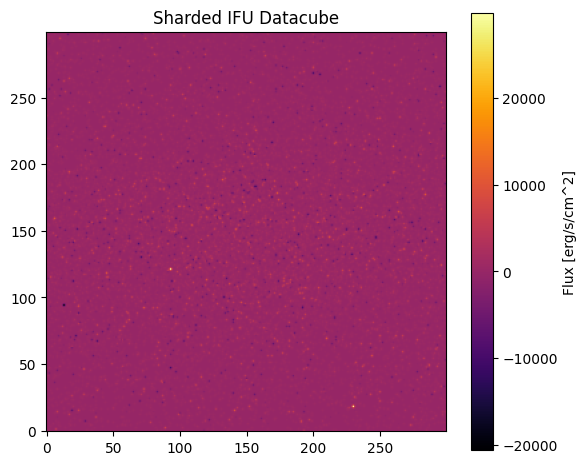

In [14]:
#NBVAL_SKIP
import numpy as np
# get the spectra of the visible wavelengths from the ifu cube
#visible_spectra = rubixdata.stars.datacube[ :, :, visible_indices[0]]
#visible_spectra = rubixdata[ :, :, visible_indices[0]]
sharded_visible_spectra = rubixdata[ :, :, visible_indices[0]]
#visible_spectra.shape

#image = jnp.sum(visible_spectra, axis=2)
sharded_image = jnp.sum(sharded_visible_spectra, axis=2)
img32 = np.array(sharded_image, dtype=np.float32)

# Plot side by side
plt.figure(figsize=(6, 5))

# Original IFU datacube image
#im0 = axes[0].imshow(image, origin="lower", cmap="inferno")
#axes[0].set_title("Original IFU Datacube")
#fig.colorbar(im0, ax=axes[0])

# Sharded IFU datacube image
plt.imshow(img32, origin="lower", cmap="inferno")
plt.title("Sharded IFU Datacube")
plt.colorbar(label="Flux [erg/s/cm^2]")

plt.tight_layout()
plt.savefig(f"./output/emiles/image_{galaxy_id}_{component}.jpeg")
plt.show()

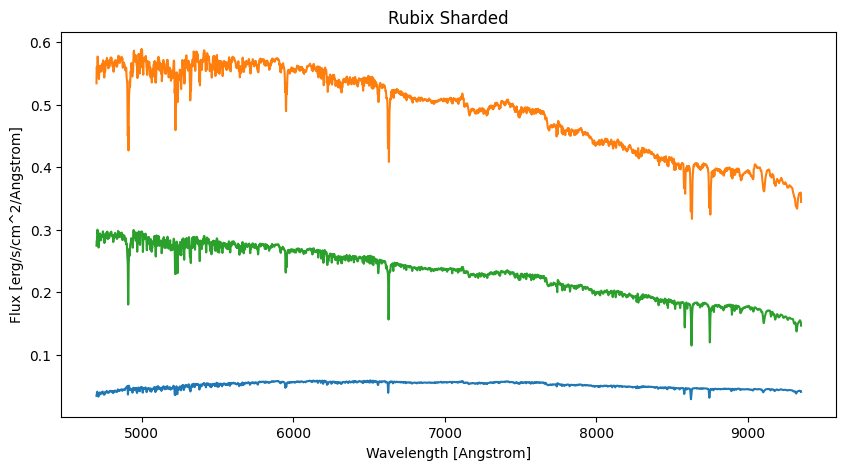

In [15]:
#NBVAL_SKIP
wave = pipe.telescope.wave_seq

#spectra = rubixdata#.stars.datacube # Spectra of all stars
spectra_sharded = rubixdata # Spectra of all stars
#print(spectra.shape)

plt.figure(figsize=(10, 5))
#plt.subplot(1, 2, 1)
#plt.title("Rubix")
#plt.xlabel("Wavelength [Angstrom]")
#plt.ylabel("Flux [erg/s/cm^2/Angstrom]")
#plt.plot(wave, spectra[12,12,:])
#plt.plot(wave, spectra[8,12,:])

#plt.subplot(1, 2, 2)
plt.title("Rubix Sharded")
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Flux [erg/s/cm^2/Angstrom]")
plt.plot(wave, spectra_sharded[150,150,:])
plt.plot(wave, spectra_sharded[150,200,:])
plt.plot(wave, spectra_sharded[200,150,:])

plt.savefig(f"./output/emiles/spectra_{galaxy_id}_{component}.jpeg")
plt.show()

## DONE!

Congratulations, you have sucessfully run the RUBIX pipeline to create your own mock-observed IFU datacube! Now enjoy playing around with the RUBIX pipeline and enjoy doing amazing science with RUBIX :)

In [16]:
# NBVAL_SKIP
from rubix.core.rotation import get_galaxy_rotation
rotate = get_galaxy_rotation(config_NIHAO)

inputdata = rotate(inputdata)

2025-10-01 11:43:45,040 - rubix - DEBUG - Roataion Type found: matrix


2025-10-01 11:43:45,042 - rubix - INFO - Rotating galaxy with alpha=0.0, beta=0.0, gamma=0.0


2025-10-01 11:43:45,043 - rubix - DEBUG - Rotation type is matrix, loading rotation matrix from file.


2025-10-01 11:43:45,057 - rubix - INFO - Using rotation matrix from file: [[ 0.9881036   0.00580573  0.15368009]
 [-0.1537897   0.03730198  0.9873993 ]
 [ 0.         -0.9992872   0.03775109]].


In [17]:
from rubix.core.telescope import get_spaxel_assignment
bin_particles = get_spaxel_assignment(config_NIHAO)

inputdata = bin_particles(inputdata)

/home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /home/annalena/.conda/envs/rubix/lib/python3.12/site-packages/rubix/telescope/telescopes.yaml
  warnings.warn(
2025-10-01 11:43:45,402 - rubix - INFO - Calculating spatial bin edges...


2025-10-01 11:43:45,412 - rubix - INFO - Getting cosmology...


2025-10-01 11:43:45,414 - rubix - INFO - Assigning particles to spaxels...


/tmp/ipykernel_292807/2343321222.py:14: RuntimeWarning: invalid value encountered in divide
  mean_velocity = sum_velocity / counts


nan
nan


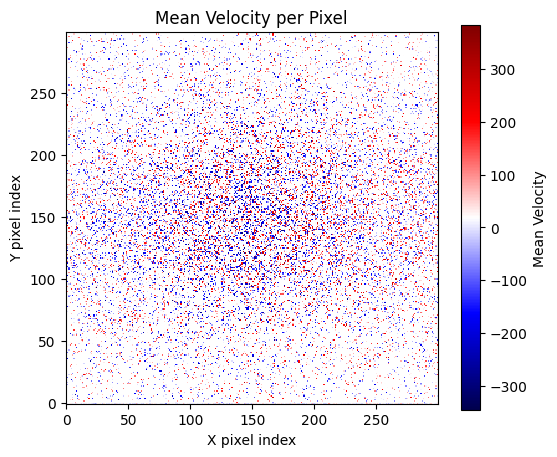

In [18]:
# NBVAL_SKIP
import numpy as np
import matplotlib.pyplot as plt

# Assuming your data arrays are defined as follows:
pixel_assignment = np.asarray(np.squeeze(inputdata.stars.pixel_assignment))
velocities = np.asarray(inputdata.stars.velocity[:, 2])

# Compute the sum of velocities and count per pixel using np.bincount
sum_velocity = np.bincount(pixel_assignment, weights=velocities)
counts = np.bincount(pixel_assignment)

# Calculate mean velocity; note: division by zero is avoided if every pixel has at least one star.
mean_velocity = sum_velocity / counts


# If you know the pixel grid dimensions (for example, a square grid)
n_pixels = len(mean_velocity)
grid_size = int(np.sqrt(n_pixels))
if grid_size * grid_size != n_pixels:
    raise ValueError("The total number of pixels is not a perfect square; please specify the grid shape explicitly.")

# Reshape the mean_velocity into a 2D array for imshow
velocity_map = mean_velocity.reshape((grid_size, grid_size))
print(velocity_map[12,12])

print(velocity_map[17,12]-velocity_map[7,12])
# Plot the result
plt.figure(figsize=(6, 5))
plt.imshow(velocity_map, origin='lower', interpolation='nearest', cmap='seismic')
plt.colorbar(label='Mean Velocity')
plt.title('Mean Velocity per Pixel')
plt.xlabel('X pixel index')
plt.ylabel('Y pixel index')
#storepath = f"./output/datacube_NIHAO{config_illustris['data']['load_galaxy_args']['id']}_{config_illustris["telescope"]["name"]}_{config_illustris['pipeline']['name']}_velocity.png"
#plt.savefig(storepath)
plt.savefig(f"./output/emiles/mean_vel_{galaxy_id}_{component}.jpeg")
plt.show()

/tmp/ipykernel_292807/2773981002.py:14: RuntimeWarning: invalid value encountered in divide
  mean_age = sum_ages / counts


nan


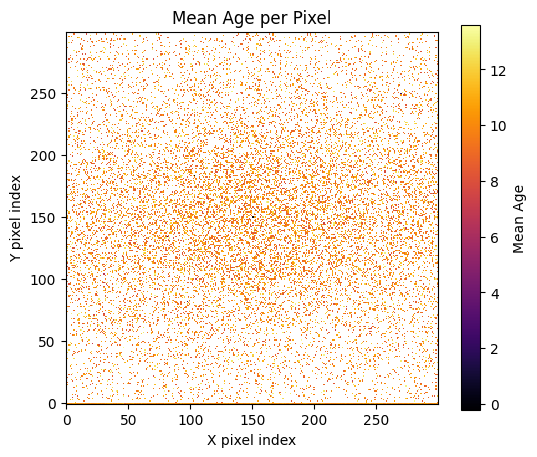

In [19]:
# NBVAL_SKIP
import numpy as np
import matplotlib.pyplot as plt

# Assuming your data arrays are defined as follows:
pixel_assignment = np.asarray(np.squeeze(inputdata.stars.pixel_assignment))
ages = np.asarray(inputdata.stars.age[:])

# Compute the sum of velocities and count per pixel using np.bincount
sum_ages = np.bincount(pixel_assignment, weights=ages)
counts = np.bincount(pixel_assignment)

# Calculate mean velocity; note: division by zero is avoided if every pixel has at least one star.
mean_age = sum_ages / counts


# If you know the pixel grid dimensions (for example, a square grid)
n_pixels = len(mean_age)
grid_size = int(np.sqrt(n_pixels))
if grid_size * grid_size != n_pixels:
    raise ValueError("The total number of pixels is not a perfect square; please specify the grid shape explicitly.")

# Reshape the mean_velocity into a 2D array for imshow
age_map = mean_age.reshape((grid_size, grid_size))
print(age_map[12,12])

# Plot the result
plt.figure(figsize=(6, 5))
plt.imshow(age_map, origin='lower', interpolation='nearest', cmap='inferno')
plt.colorbar(label='Mean Age')
plt.title('Mean Age per Pixel')
plt.xlabel('X pixel index')
plt.ylabel('Y pixel index')
#storepath = f"./output/datacube_NIHAO{config_illustris['data']['load_galaxy_args']['id']}_{config_illustris["telescope"]["name"]}_{config_illustris['pipeline']['name']}_age.png"
#plt.savefig(storepath)
plt.savefig(f"./output/emiles/mean_age_{galaxy_id}_{component}.jpeg")
plt.show()

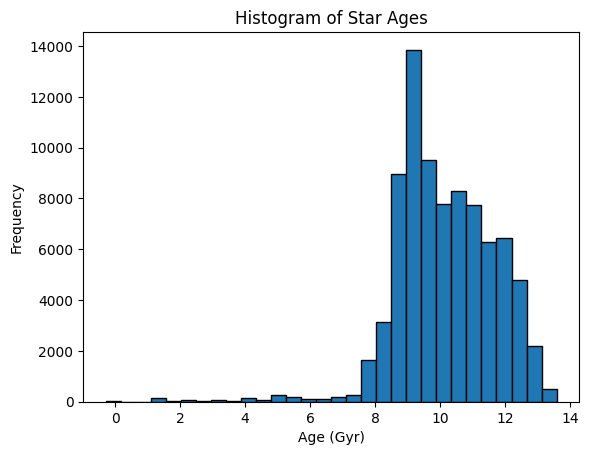

In [20]:
# NBVAL_SKIP
import matplotlib.pyplot as plt

# Plot a histogram of the velocities
plt.hist(inputdata.stars.age[:], bins=30, edgecolor='black')
plt.xlabel('Age (Gyr)')
plt.ylabel('Frequency')
plt.title('Histogram of Star Ages')
plt.savefig(f"./output/emiles/age_{galaxy_id}_{component}.jpeg")
plt.show()

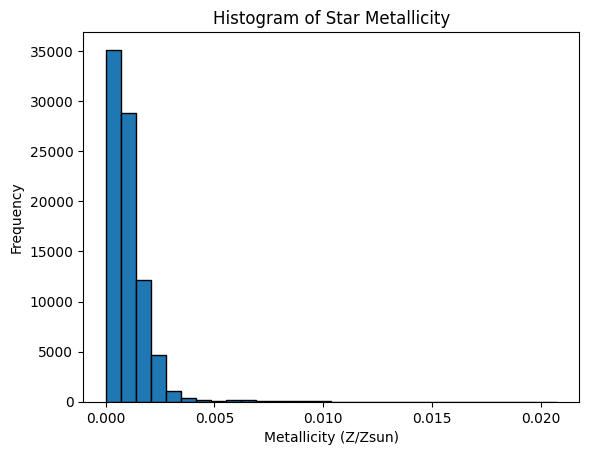

In [21]:
# NBVAL_SKIP
import matplotlib.pyplot as plt

# Plot a histogram of the velocities
plt.hist(inputdata.stars.metallicity[:], bins=30, edgecolor='black')
plt.xlabel('Metallicity (Z/Zsun)')
plt.ylabel('Frequency')
plt.title('Histogram of Star Metallicity')
plt.savefig(f"./output/emiles/metallicity_{galaxy_id}_{component}.jpeg")
plt.show()